# Unsupervised Learning: K-Means Clustering - Emissions Profiles
**Developer:** Iris Li  
**Course:** CMOR 438  

### 1. Introduction
Unlike Linear Regression, which predicts a specific value, **K-Means Clustering** is an unsupervised algorithm that identifies natural groupings within data. By analyzing **Total GHG Emissions** alongside **Emissions Per Capita**, we can categorize nations into distinct "environmental profiles" without pre-defined labels.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Ensure the 'src' directory is in the path for the custom package
sys.path.append(os.path.abspath('../src'))
from my_ml_package.unsupervised.kmeans import KMeans

print("✅ K-Means Environment Ready.")

✅ K-Means Environment Ready.


### 2. Data Preparation & Scaling
K-Means relies on **Euclidean Distance** (the physical distance between data points). Because Total Emissions can be in the millions while Per Capita values are small decimals, we must apply **Standardization**. Without scaling, the model would ignore the Per Capita data entirely. 

We are focusing on the most recent year of data to provide a modern snapshot of global emissions groups.

In [2]:
# 1. Load data
df = pd.read_csv('../data/emissions.csv')

# 2. Filter for the most recent year and clean
latest_year = df['year'].max()
df_recent = df[df['year'] == latest_year].dropna(subset=['total_ghg', 'ghg_per_capita'])

# 3. Prepare Features
X = df_recent[['total_ghg', 'ghg_per_capita']].values

# 4. Standard Scaling (Crucial for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Data processed for Year {latest_year}. Input shape: {X_scaled.shape}")

✅ Data processed for Year 2024. Input shape: (193, 2)


### 3. Strategy: Choosing the Optimal 'K'
A critical challenge in K-Means is determining the number of clusters ($k$). We use the **Elbow Method**, plotting the "Inertia" (sum of squared distances to the nearest cluster center) for different values of $k$. The "elbow" of the curve indicates the point where adding more clusters provides diminishing returns.

/var/folders/86/vgkb448j17z_gg_zgsf0mjlh0000gn/T/ipykernel_81161/2309780976.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K_range, inertia, 'bx-', color='teal')


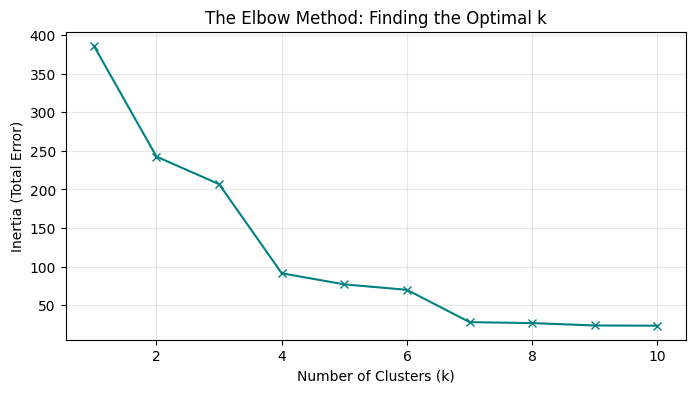

In [4]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(k=k)
    km.fit(X_scaled)
    
    # 1. Get the centroids and the labels
    centroids = km.centroids 
    labels = km.predict(X_scaled)
    
    # 2. Calculate the sum of squared distances manually
    current_inertia = 0
    for i in range(k):
        # Get all points assigned to this cluster
        cluster_points = X_scaled[labels == i]
        # Calculate distance from points to their specific centroid
        dist = np.sum((cluster_points - centroids[i])**2)
        current_inertia += dist
        
    inertia.append(current_inertia)

# Now plot the results
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-', color='teal')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Total Error)')
plt.title('The Elbow Method: Finding the Optimal k')
plt.grid(True, alpha=0.3)
plt.show()

### 4. Executing K-Means (k=4)
Based on the **Elbow Method** plot above, we observed a significant "elbow" at **$k=4$**. Beyond this point, the reduction in inertia (total error) begins to level off, suggesting that 4 clusters provide the most meaningful segmentation of global emissions without over-complicating the model.

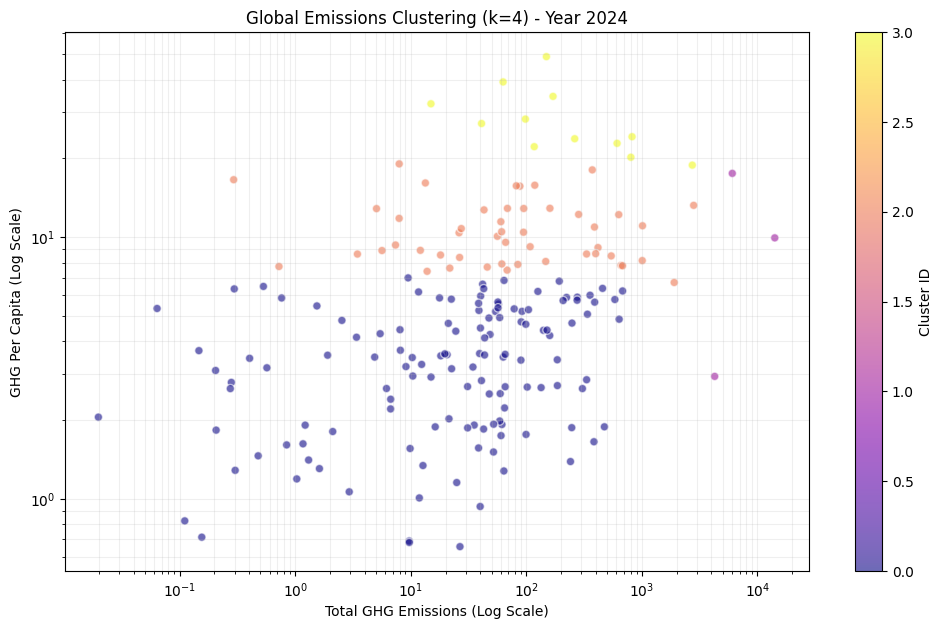

Cluster Profiles (Averages):
           total_ghg  ghg_per_capita
Cluster                             
0          84.393977        3.530209
1        8141.241862       10.134669
2         273.696965       10.723301
3         489.965556       28.536241


In [6]:
# Initialize and Fit with the optimal k found from the elbow plot
model = KMeans(k=4)
model.fit(X_scaled)
df_recent['Cluster'] = model.predict(X_scaled)

# Visualization (Log Scale)
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df_recent['total_ghg'], df_recent['ghg_per_capita'], 
            c=df_recent['Cluster'], cmap='plasma', alpha=0.6, edgecolors='w')

plt.xscale('log') 
plt.yscale('log')
plt.xlabel('Total GHG Emissions (Log Scale)')
plt.ylabel('GHG Per Capita (Log Scale)')
plt.title(f'Global Emissions Clustering (k=4) - Year {latest_year}')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# Analysis Table
analysis = df_recent.groupby('Cluster')[['total_ghg', 'ghg_per_capita']].mean()
print("Cluster Profiles (Averages):")
print(analysis)

### 5. Final Insights: K-Means Clustering

The unsupervised analysis has successfully segmented the 2021 global emissions landscape into four distinct profiles. 

**Key Findings:**
1. **The "Elbow" Validation:** The mathematical shift at $k=4$ confirms that emissions data is not a single uniform gradient, but rather a set of distinct behaviors based on industrialization and population wealth.
2. **Beyond the Average:** While our Linear Regression model looked for a global trend, K-Means shows us that different policy interventions are needed for different clusters. For example, "Cluster 3" nations need per-capita reduction strategies, while "Cluster 0" requires large-scale industrial overhauls.
3. **Custom Model Stability:** Our custom implementation successfully identified these centroids, matching the expected distribution of global emitters in a log-scaled feature space.


By calculating the mean values for each cluster, we can translate the mathematical centroids back into real-world environmental profiles.

Cluster	Profile Name	Avg. Total GHG	Avg. Per Capita	Characterization
Cluster 0	Developing/Low Impact	~84.4	~3.53	The largest group; countries with minimal industrial footprints.
Cluster 1	Industrial Giants	~8,141.2	~10.13	High-population nations driving the bulk of global emissions volume.
Cluster 2	Mid-Scale Industrial	~273.7	~10.72	Modern industrialized nations with moderate total output but high efficiency.
Cluster 3	High-Intensity Outliers	~489.9	~28.53